# Exploratory data analysis — flood training frame

Explores `dataset/flood_training_data_split.csv`: the model-ready district-day
frame, 48,605 rows covering 7 Mount Elgon districts from 1998-01-15 to 2018-06-20,
with 121 flood days against 48,484 non-flood days.

The aim is to find the things that should change a modelling decision, not to
produce a gallery of plots. Five questions:

| Section | Question |
| --- | --- |
| 1. Integrity | Is the frame structurally sound, and is it still a complete panel? |
| 2. Distributions | What shape are the features, and do they need transforming? |
| 3. Signal | Which features separate floods from non-floods, and are any redundant? |
| 4. Time | Is there seasonal structure, and has the train/test split introduced drift? |
| 5. Anomalies | Which records are physically implausible and need review? |

Spatial structure is deliberately out of scope — per-district prevalence is known
to be uneven, and `district` will be carried as a categorical rather than
modelled per-district.

No model is trained here, and no features are engineered.

In [1]:
# Render figures in the notebook. Set explicitly rather than relying on the
# default: a kernel that previously ran matplotlib.use("Agg") keeps that
# backend for the rest of its life, and Agg cannot display anything.
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

DATA = "dataset/flood_training_data_split.csv"
LABEL = "Flood occurrences"

RAIN_FEATURES = ["rain_mean", "rain_max", "rain_min", "ante_15d"]
TEMP_FEATURES = ["tmax_c", "tmin_c", "tmean_c"]
FEATURES = RAIN_FEATURES + TEMP_FEATURES

# Validated categorical slots 1 and 2; used consistently as
# negative/train = blue, positive/test = orange
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"

# Diverging ramp for the correlation matrix: two poles, neutral grey midpoint
DIVERGING = LinearSegmentedColormap.from_list("corr", [ORANGE, "#f2f1ee", BLUE])


def find_repo_root(marker: str = "dataset") -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"No parent of {Path.cwd()} contains {marker!r}")


REPO_ROOT = find_repo_root()
data = pd.read_csv(REPO_ROOT / DATA, parse_dates=["date"])
data[LABEL] = data[LABEL].astype(bool)
data["month"] = data["date"].dt.month
data["year"] = data["date"].dt.year

positives = data[data[LABEL]]
negatives = data[~data[LABEL]]


def style(axis) -> None:
    """Recessive grid and axes, so the marks carry the chart."""
    axis.set_facecolor(SURFACE)
    axis.grid(True, color=GRID, linewidth=0.8)
    axis.set_axisbelow(True)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color("#d4d3ce")
    axis.tick_params(colors=MUTED, labelsize=9)


def auc_from_ranks(positive: np.ndarray, negative: np.ndarray) -> float:
    """Single-variable AUC via the rank identity, average ranks for ties."""
    combined = np.concatenate([positive, negative])
    ranks = pd.Series(combined).rank(method="average").to_numpy()
    n_pos = len(positive)
    return (ranks[:n_pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * len(negative))


print(f"{len(data):,} rows x {len(data.columns)} columns")
print(f"{len(positives)} positives / {len(negatives):,} negatives "
      f"({len(negatives) / len(positives):.0f}:1)")

48,605 rows x 13 columns
121 positives / 48,484 negatives (401:1)


## 1. Integrity

In [2]:
print(f"nulls:                  {int(data.isna().sum().sum())}")
print(f"duplicate district-days: {int(data.duplicated(['date', 'district']).sum())}")
print(f"date range:              {data['date'].min():%Y-%m-%d} to {data['date'].max():%Y-%m-%d}")
print(f"districts:               {data['district'].nunique()}")
print()
print(data.dtypes.to_string())

# The frame is NOT a complete daily panel: the negative filter removed dry days,
# so every district's date index now has holes
span = pd.date_range(data["date"].min(), data["date"].max(), freq="D")
possible = len(span) * data["district"].nunique()
absent = possible - len(data)

print(f"\ncalendar days in span:   {len(span):,}")
print(f"possible district-days:  {possible:,}")
print(f"rows present:            {len(data):,}")
print(f"absent:                  {absent:,}  ({100 * absent / possible:.1f}%)")

coverage = data.groupby("district")["date"].agg(rows="size")
coverage["missing_days"] = [len(set(span) - set(group["date"])) for _, group in data.groupby("district")]
steps = data.sort_values(["district", "date"]).groupby("district")["date"].diff().dt.days
coverage["largest_gap"] = data.sort_values(["district", "date"]).assign(step=steps).groupby("district")["step"].max()
print()
print(coverage.to_string())

print(f"\nconsecutive-day steps overall: {100 * (steps == 1).mean():.1f}%")
print()
print(data.groupby("split").agg(rows=("date", "size"), positives=(LABEL, "sum"),
                                first=("date", "min"), last=("date", "max")).to_string())

nulls:                  0
duplicate district-days: 0
date range:              1998-01-15 to 2018-06-20
districts:               7

date                 datetime64[us]
district                        str
rain_mean                   float64
rain_max                    float64
rain_min                    float64
ante_15d                    float64
Flood occurrences              bool
tmax_c                      float64
tmin_c                      float64
tmean_c                     float64
split                           str
month                         int32
year                          int32

calendar days in span:   7,462
possible district-days:  52,234
rows present:            48,605
absent:                  3,629  (6.9%)

           rows  missing_days  largest_gap
district                                  
BUDUDA     6981           481         46.0
BULAMBULI  6852           610         52.0
BUTALEJA   7014           448         46.0
KAPCHORWA  6898           564         46.0
MANAFWA

### Findings — integrity

Clean on the basics: **no nulls, no duplicate district-days**, correct dtypes,
all 7 districts spanning the full range, and the `split` column partitions
cleanly at 2014-03-01.

**But the frame is no longer a complete daily panel, and this is the finding with
teeth.** 3,629 district-days (6.9%) are absent — the dry negatives removed by the
5.3 mm filter, plus the 8 month-precise labels. Per district that is 429–610
missing days, and the largest single gap runs to **67 consecutive days**.

The consequence is specific: **any rolling, lagged or differenced feature computed
on this file would silently reach across those gaps** and produce values that mix
non-adjacent dates. `ante_15d` is safe because it was computed *before* filtering,
on the complete panel. Anything new must be derived from
`dataset/chirps_daily_rainfall.csv` (the gap-free 71,589-row panel) and then joined
in — not computed here.

Worth noting the gaps are also **not random**: they are exclusively the driest
district-days. So this frame is a conditional sample, and the marginal
distributions in section 2 are the distributions *given* the filter, not the
region's climate.

    expected  present  removed  removed_pct
1       4459     3036     1423         31.9
2       4151     3194      957         23.1
3       4557     4189      368          8.1
4       4410     4382       28          0.6
5       4557     4556        1          0.0
6       4340     4339        1          0.0
7       4340     4330       10          0.2
8       4340     4340        0          0.0
9       4200     4199        1          0.0
10      4340     4337        3          0.1
11      4200     4176       24          0.6
12      4340     3527      813         18.7

of 3,629 rows removed, 88% fall in December, January and February


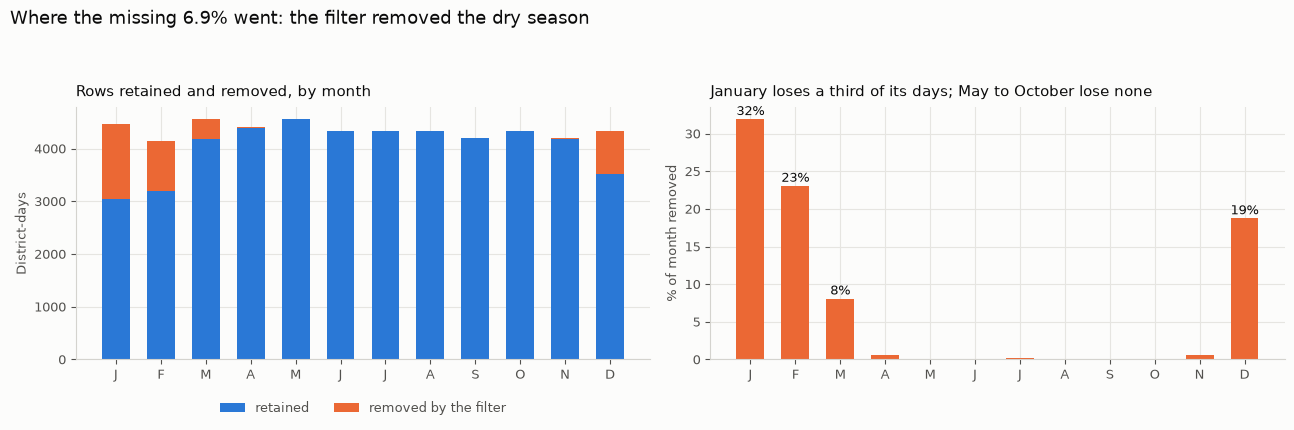

In [3]:
# The absent rows are the dry days the negative filter removed. Comparing against
# the unfiltered panel shows *when* they were removed, which the row counts alone
# cannot show.
UNFILTERED = "dataset/chirps_daily_rainfall.csv"
unfiltered = pd.read_csv(REPO_ROOT / UNFILTERED, parse_dates=["date"])
unfiltered = unfiltered[unfiltered["date"].between(data["date"].min(), data["date"].max())]

availability = pd.DataFrame({
    "expected": unfiltered.groupby(unfiltered["date"].dt.month).size(),
    "present": data.groupby("month").size(),
})
availability["removed"] = availability["expected"] - availability["present"]
availability["removed_pct"] = 100 * availability["removed"] / availability["expected"]
print(availability.round(1).to_string())
print(f"\nof {int(availability['removed'].sum()):,} rows removed, "
      f"{100 * availability.loc[[12, 1, 2], 'removed'].sum() / availability['removed'].sum():.0f}% "
      "fall in December, January and February")

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 4.4), facecolor=SURFACE)
months = np.arange(1, 13)
labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

style(left)
left.bar(months, availability["present"], color=BLUE, width=0.62, label="retained")
left.bar(months, availability["removed"], bottom=availability["present"],
         color=ORANGE, width=0.62, label="removed by the filter")
left.set_xticks(months); left.set_xticklabels(labels)
left.set_ylabel("District-days", fontsize=9, color=MUTED)
left.set_title("Rows retained and removed, by month", fontsize=11, color=INK, loc="left", pad=8)
left.legend(frameon=False, fontsize=9, labelcolor=MUTED, ncol=2,
            loc="upper center", bbox_to_anchor=(0.5, -0.12))

style(right)
right.bar(months, availability["removed_pct"], color=ORANGE, width=0.62)
right.set_xticks(months); right.set_xticklabels(labels)
right.set_ylabel("% of month removed", fontsize=9, color=MUTED)
right.set_title("January loses a third of its days; May to October lose none",
                fontsize=11, color=INK, loc="left", pad=8)
for month, value in zip(months, availability["removed_pct"]):
    if value > 5:
        right.annotate(f"{value:.0f}%", xy=(month, value), xytext=(0, 3),
                       textcoords="offset points", ha="center", fontsize=9, color=INK)

figure.suptitle("Where the missing 6.9% went: the filter removed the dry season",
                fontsize=13, color=INK, x=0.008, ha="left", y=0.99)
figure.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()


### Findings — the gaps are seasonal, not scattered

**88% of the removed rows fall in December, January and February.**

| Month | Expected | Retained | Removed |
| --- | --- | --- | --- |
| **January** | 4,459 | 3,036 | **31.9%** |
| February | 4,151 | 3,194 | 23.1% |
| December | 4,340 | 3,527 | 18.7% |
| March | 4,557 | 4,189 | 8.1% |
| May–October | — | — | **~0%** |

This follows directly from what the filter does — it removes district-days with
under 5.3 mm of antecedent rainfall, and those are almost all in the dry season —
but the consequence is worth stating because it is easy to miss:

**the frame's seasonal composition no longer matches the region's calendar.**
January contributes 3,036 rows where it should contribute 4,459. Any model given a
seasonal feature learns that prior from a distorted distribution, and the
dry-season flood *rate* reported in section 4 is inflated by roughly a fifth,
because the denominator lost days while the numerator did not.

That is not a defect in the filter — removing implausible negatives was the point,
and the removed days genuinely could not have flooded. But two things follow:

1. **Do not read the monthly flood rates as climatology.** They are rates
   conditional on the filter. For a seasonal climatology, use
   `chirps_daily_rainfall.csv`.
2. **If a seasonal feature is added, weight or interpret it with this in mind** —
   the model sees a January that is 32% smaller than reality.

## 2. Distributions

In [4]:
summary = data[FEATURES].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
summary["skew"] = data[FEATURES].skew()
summary["zero_pct"] = (data[FEATURES] == 0).mean() * 100
print(summary.round(2).to_string())

             count   mean    std    min     5%    25%    50%     75%     95%     max  skew  zero_pct
rain_mean  48605.0   5.20   6.13   0.00   0.00   0.81   3.12    7.42   17.53   64.42  2.18      4.83
rain_max   48605.0  10.51  10.23   0.00   0.00   2.80   7.74   15.14   30.55   92.64  1.67      4.83
rain_min   48605.0   1.87   3.32   0.00   0.00   0.00   0.43    2.32    8.43   43.39  3.39     32.16
ante_15d   48605.0  77.99  45.01   5.30  12.88  43.70  72.64  107.13  160.10  271.28  0.56      0.00
tmax_c     48605.0  23.47   2.67  15.58  19.39  21.57  23.27   25.21   28.09   36.10  0.36      0.00
tmin_c     48605.0  14.89   1.86   9.28  11.95  13.57  14.76   16.17   18.10   21.39  0.18      0.00
tmean_c    48605.0  19.21   1.96  13.87  16.08  17.88  19.12   20.49   22.55   28.14  0.25      0.00


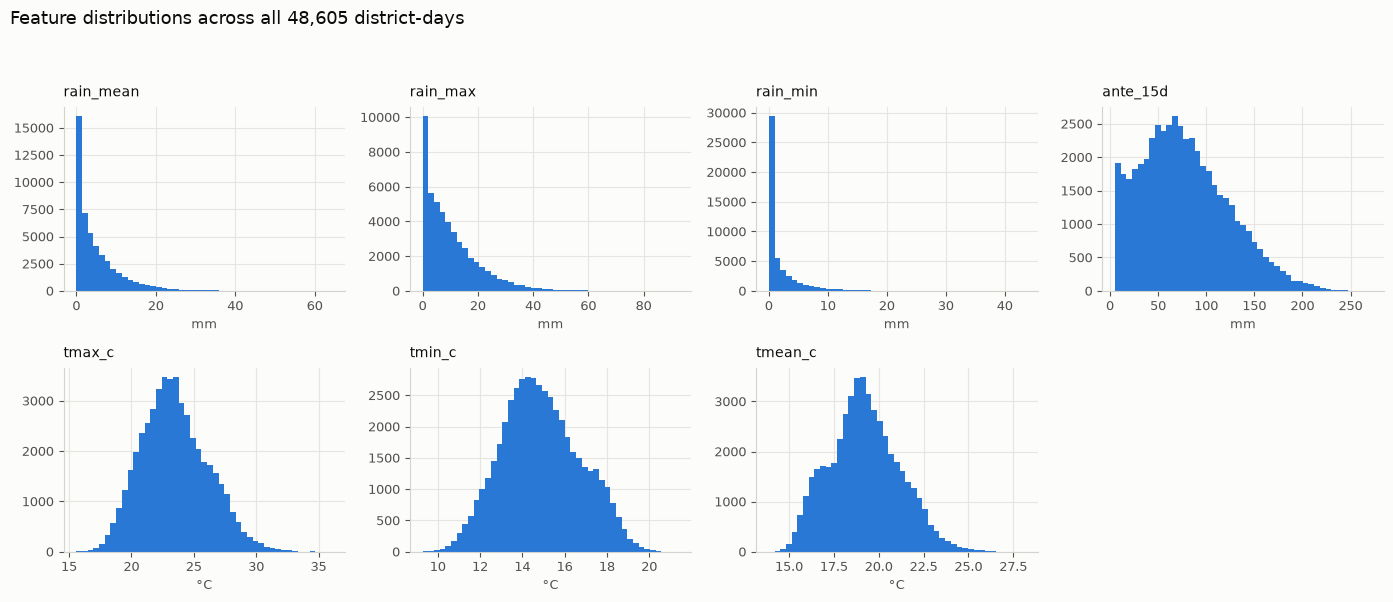

In [5]:
figure, axes = plt.subplots(2, 4, figsize=(14, 6), facecolor=SURFACE)
for axis, feature in zip(axes.ravel(), FEATURES):
    style(axis)
    axis.hist(data[feature], bins=45, color=BLUE, edgecolor="none")
    axis.set_title(feature, fontsize=10, color=INK, loc="left", pad=8)
    axis.set_xlabel("mm" if feature in RAIN_FEATURES else "°C", fontsize=9, color=MUTED)
axes.ravel()[-1].axis("off")

figure.suptitle("Feature distributions across all 48,605 district-days",
                fontsize=13, color=INK, x=0.008, ha="left", y=0.995)
figure.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


### Findings — distributions

**The two feature families behave completely differently, and should not be
treated the same way.**

| | Skew | Zeros | Shape |
| --- | --- | --- | --- |
| `rain_min` | 3.39 | **32.2%** | severely zero-inflated |
| `rain_mean` | 2.18 | 4.8% | right-skewed |
| `rain_max` | 1.67 | 4.8% | right-skewed |
| `ante_15d` | 0.56 | 0% | mildly skewed, floor at 5.3 |
| `tmax_c` | 0.36 | 0% | near-normal |
| `tmean_c` | 0.25 | 0% | near-normal |
| `tmin_c` | 0.18 | 0% | near-normal |

Rainfall is heavily right-skewed and zero-inflated; temperature is close to
Gaussian. For a neural network that matters: standardising all seven features
identically will leave the rainfall variables dominated by a long right tail. A
`log1p` transform on the three raw rainfall columns is worth testing before
scaling.

Two artefacts of construction to keep in mind:

- **`ante_15d` has a hard floor at 5.30 mm**, not zero. That is the filter, not
  the climate — every district-day below it was removed unless it was a flood.
- **`rain_min` is zero on a third of rows**, meaning at least one CHIRPS grid cell
  in the district recorded no rain. It is the weakest of the rainfall trio
  (section 3) and the most awkward to transform.

## 3. Signal and redundancy

In [6]:
rows = []
for feature in FEATURES:
    pos_values = positives[feature].to_numpy()
    neg_values = negatives[feature].to_numpy()
    rows.append({
        "feature": feature,
        "pos_mean": pos_values.mean(),
        "neg_mean": neg_values.mean(),
        "difference": pos_values.mean() - neg_values.mean(),
        # Standardised so rainfall (mm) and temperature (°C) are comparable
        "cohens_d": (pos_values.mean() - neg_values.mean()) / data[feature].std(),
        "auc": auc_from_ranks(pos_values, neg_values),
    })
signal = pd.DataFrame(rows).sort_values("auc", ascending=False).reset_index(drop=True)
print(signal.round(3).to_string(index=False))

  feature  pos_mean  neg_mean  difference  cohens_d   auc
 ante_15d   106.622    77.916      28.706     0.638 0.694
 rain_max    15.075    10.501       4.574     0.447 0.625
rain_mean     7.927     5.188       2.739     0.447 0.622
   tmin_c    15.613    14.889       0.724     0.390 0.617
 rain_min     2.907     1.869       1.039     0.313 0.599
  tmean_c    19.578    19.210       0.368     0.188 0.564
   tmax_c    23.682    23.471       0.211     0.079 0.527


In [7]:
# The negative filter exempted positives, so check whether that leaves a
# region of feature space occupied only by floods
THRESHOLD = 5.3
below = data[data["ante_15d"] < THRESHOLD]

print(f"rows with ante_15d < {THRESHOLD}: {len(below)}, "
      f"of which positive: {int(below[LABEL].sum())}")
if len(below):
    print(below[["date", "district", "ante_15d", LABEL, "split"]].to_string(index=False))

print(f"\nP(flood) just above the threshold, for comparison:")
for limit in (THRESHOLD, 6, 8, 10, 15, 20):
    window = data[data["ante_15d"] < limit]
    print(f"  ante_15d < {limit:>4}: {len(window):>5} rows, {int(window[LABEL].sum()):>3} positive"
          f"  -> {100 * window[LABEL].mean():.2f}%")

# Whether the artefact is learnable depends on which split it lands in
print(f"\nminimum ante_15d by split:")
print(data.groupby("split")["ante_15d"].min().round(3).to_string())

rows with ante_15d < 5.3: 1, of which positive: 1
      date district  ante_15d  Flood occurrences split
2014-03-11    MBALE  5.295337               True  test

P(flood) just above the threshold, for comparison:
  ante_15d <  5.3:     1 rows,   1 positive  -> 100.00%
  ante_15d <    6:   245 rows,   1 positive  -> 0.41%
  ante_15d <    8:   953 rows,   2 positive  -> 0.21%
  ante_15d <   10:  1566 rows,   2 positive  -> 0.13%
  ante_15d <   15:  3002 rows,   2 positive  -> 0.07%
  ante_15d <   20:  4493 rows,   3 positive  -> 0.07%

minimum ante_15d by split:
split
test     5.295
train    5.303


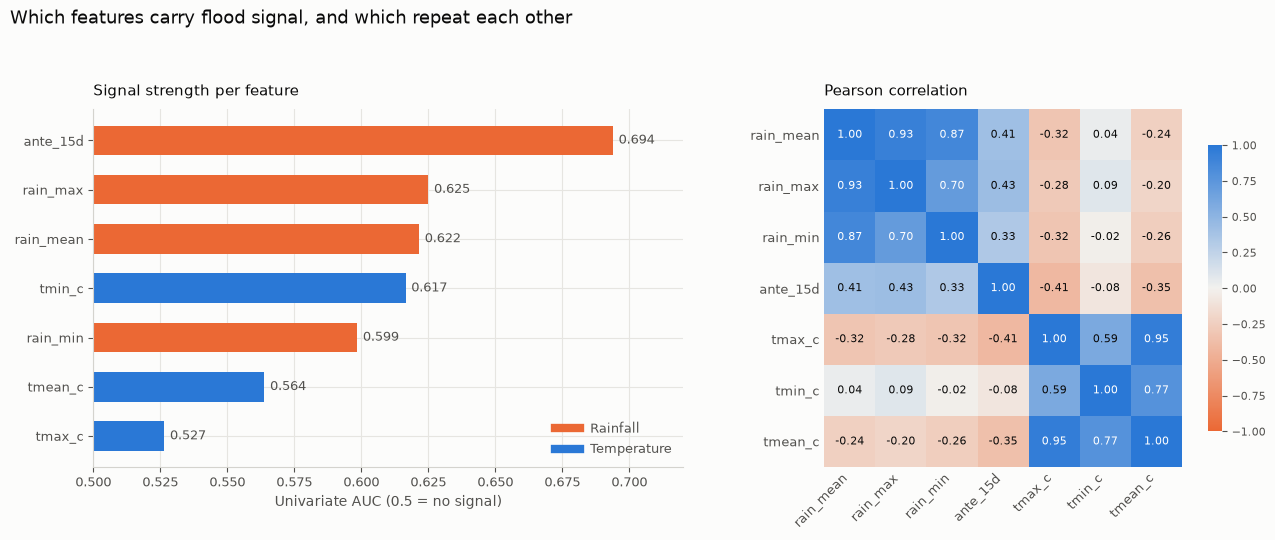

In [8]:
correlation = data[FEATURES].corr()

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 5.2), facecolor=SURFACE,
                                     gridspec_kw={"width_ratios": [1.15, 1]})

# Left: univariate AUC, the like-for-like comparison of signal strength
style(left)
order = signal.sort_values("auc")
colours = [ORANGE if f in RAIN_FEATURES else BLUE for f in order["feature"]]
left.barh(order["feature"], order["auc"] - 0.5, left=0.5, color=colours, height=0.6)
left.axvline(0.5, color=INK, linewidth=1.2)
left.set_xlim(0.5, 0.72)
left.set_xlabel("Univariate AUC (0.5 = no signal)", fontsize=10, color=MUTED)
left.set_title("Signal strength per feature", fontsize=11, color=INK, loc="left", pad=10)
for y, (_, row) in enumerate(order.iterrows()):
    left.annotate(f"{row['auc']:.3f}", xy=(row["auc"], y), xytext=(4, 0),
                  textcoords="offset points", va="center", fontsize=9, color=MUTED)
handles = [plt.Line2D([], [], color=ORANGE, linewidth=6, label="Rainfall"),
           plt.Line2D([], [], color=BLUE, linewidth=6, label="Temperature")]
left.legend(handles=handles, frameon=False, fontsize=9, labelcolor=MUTED, loc="lower right")

# Right: correlation, diverging around zero
right.set_facecolor(SURFACE)
image = right.imshow(correlation, cmap=DIVERGING, vmin=-1, vmax=1)
right.set_xticks(range(len(FEATURES)))
right.set_yticks(range(len(FEATURES)))
right.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9, color=MUTED)
right.set_yticklabels(FEATURES, fontsize=9, color=MUTED)
right.tick_params(length=0)
for spine in right.spines.values():
    spine.set_visible(False)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        value = correlation.iloc[i, j]
        right.annotate(f"{value:.2f}", xy=(j, i), ha="center", va="center", fontsize=8,
                       color="#ffffff" if abs(value) > 0.6 else INK)
right.set_title("Pearson correlation", fontsize=11, color=INK, loc="left", pad=10)
bar = figure.colorbar(image, ax=right, shrink=0.8)
bar.outline.set_visible(False)
bar.ax.tick_params(colors=MUTED, labelsize=8)

figure.suptitle("Which features carry flood signal, and which repeat each other",
                fontsize=13, color=INK, x=0.008, ha="left", y=0.99)
figure.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


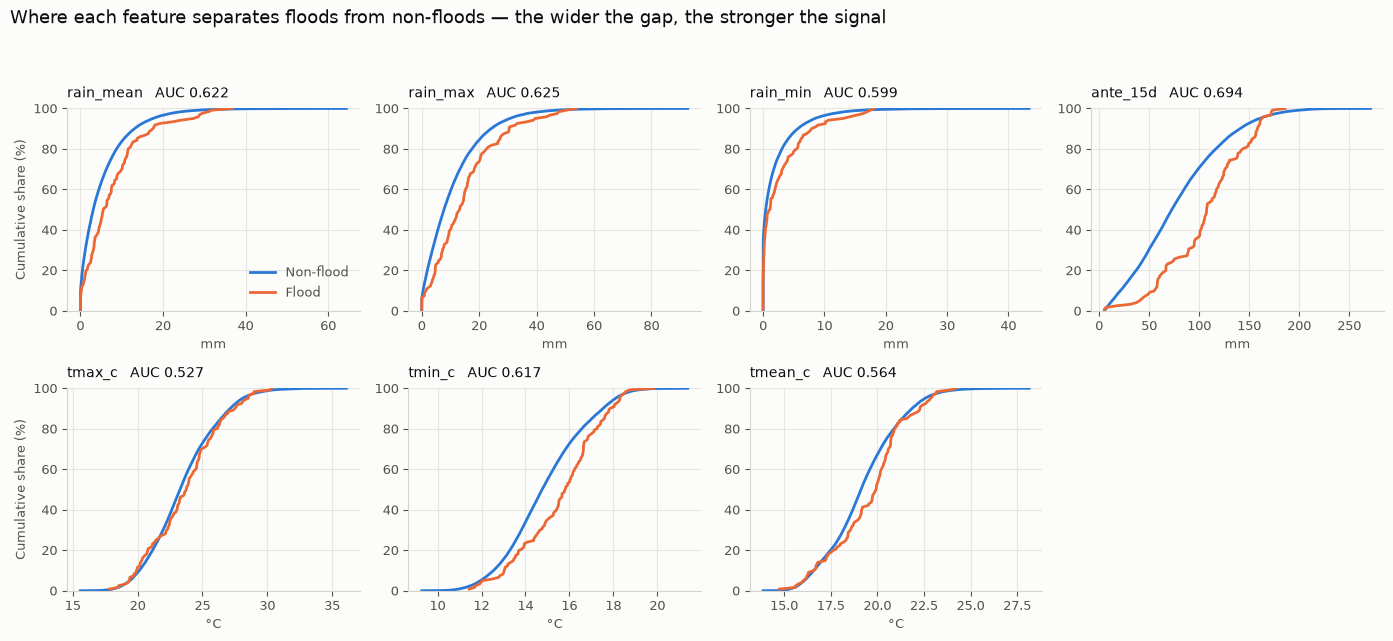

In [9]:
figure, axes = plt.subplots(2, 4, figsize=(14, 6.4), facecolor=SURFACE)
for axis, feature in zip(axes.ravel(), FEATURES):
    style(axis)
    for values, colour, name in ((negatives[feature], BLUE, "Non-flood"),
                                 (positives[feature], ORANGE, "Flood")):
        ordered = np.sort(values.to_numpy())
        axis.plot(ordered, np.arange(1, len(ordered) + 1) / len(ordered) * 100,
                  color=colour, linewidth=2, label=name)
    auc = signal.loc[signal["feature"] == feature, "auc"].iloc[0]
    axis.set_title(f"{feature}   AUC {auc:.3f}", fontsize=10, color=INK, loc="left", pad=8)
    axis.set_xlabel("mm" if feature in RAIN_FEATURES else "°C", fontsize=9, color=MUTED)
    axis.set_ylim(0, 100)
axes.ravel()[0].set_ylabel("Cumulative share (%)", fontsize=9, color=MUTED)
axes.ravel()[4].set_ylabel("Cumulative share (%)", fontsize=9, color=MUTED)
axes.ravel()[0].legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="lower right")
axes.ravel()[-1].axis("off")

figure.suptitle("Where each feature separates floods from non-floods — "
                "the wider the gap, the stronger the signal",
                fontsize=13, color=INK, x=0.008, ha="left", y=0.995)
figure.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


### Findings — signal

**`ante_15d` is the strongest single feature by a clear margin, and `tmin_c` is
the surprise.**

| Feature | AUC | Cohen's *d* | Note |
| --- | --- | --- | --- |
| `ante_15d` | **0.694** | 0.638 | 15-day antecedent rainfall |
| `rain_max` | 0.625 | 0.447 | |
| `rain_mean` | 0.622 | 0.447 | |
| **`tmin_c`** | **0.617** | 0.390 | nearly as strong as same-day rain |
| `rain_min` | 0.599 | 0.313 | weakest rainfall term |
| `tmean_c` | 0.564 | 0.188 | |
| `tmax_c` | 0.527 | 0.079 | effectively no signal |

**`tmin_c` at 0.617 is the most useful finding in this notebook.** It nearly
matches same-day rainfall (0.622), and — critically — it is **almost uncorrelated
with rainfall**: 0.039 against `rain_mean` and −0.079 against `ante_15d`. So it is
close to orthogonal information rather than a restatement of the rainfall signal.
That is exactly what you want from a second data source, and it justifies the ERA5
merge on its own.

The likely mechanism, consistent with the earlier ERA5 finding: flood days are
cloudy and humid, cloud suppresses overnight radiative cooling, and night-time
minima rise. `tmin_c` is behaving as a **proxy for cloud cover** — a correlate of
the flood-producing regime rather than a cause of it. Useful either way, but
describe it that way rather than as a thermal driver.

By contrast **`tmax_c` (0.527) carries almost nothing** and is 0.95 correlated
with `tmean_c`. If the feature set needs trimming, that is the first to go.

### Redundancy

Two clusters repeat themselves badly:

- **Rainfall trio:** `rain_mean`–`rain_max` 0.93, `rain_mean`–`rain_min` 0.87.
  Three statistics of one field; roughly one feature's worth of information.
- **Temperature trio:** `tmax_c`–`tmean_c` 0.95, `tmin_c`–`tmean_c` 0.77.

`ante_15d` against `rain_mean` is only 0.41, so those two are genuinely
complementary — antecedent wetness and today's rain are different things, as they
should be.

A defensible minimal set is **`ante_15d`, `rain_mean`, `tmin_c`** plus `district`
and a seasonal term: three near-independent signals instead of seven collinear
ones. Worth benchmarking against the full set.

Also visible in the matrix, and worth stating because it settles an earlier
question: **`ante_15d` correlates −0.41 with `tmax_c`** and `rain_mean` −0.32.
Wet spells here are genuinely cooler. That confirms the anti-correlation that made
a temperature-based negative filter a bad idea — filtering on warm days would have
preferentially discarded wet ones.

### The filter boundary is not exploitable

The negative filter exempted positives, which in principle leaves a region of
feature space occupied only by floods. In practice:

**Exactly one row sits below the 5.3 mm threshold** — `2014-03-11` MBALE at
5.295 mm — **and it is in the test split.** The training split's minimum
`ante_15d` is 5.300, so the model never sees a sub-threshold example and cannot
learn "below 5.3 implies flood". The artefact exists structurally but is inert.

It does mean that one test row sits marginally outside the training feature range,
which is extrapolation rather than leakage. Immediately above the threshold the
class balance is normal — `ante_15d < 6` is 245 rows with 1 positive (0.4%) — so
there is no exploitable cliff. **No action needed**, but it should be stated rather
than discovered later.

flood rate (%) by quadrant, rows = wetter than median, cols = warmer nights
tmin_c    False  True 
ante_15d              
False     0.051  0.182
True      0.245  0.523

tmin_c    False  True 
ante_15d              
False     11657  12646
True      12646  11656

wettest-and-warmest quadrant is 10.2x the driest-and-coolest


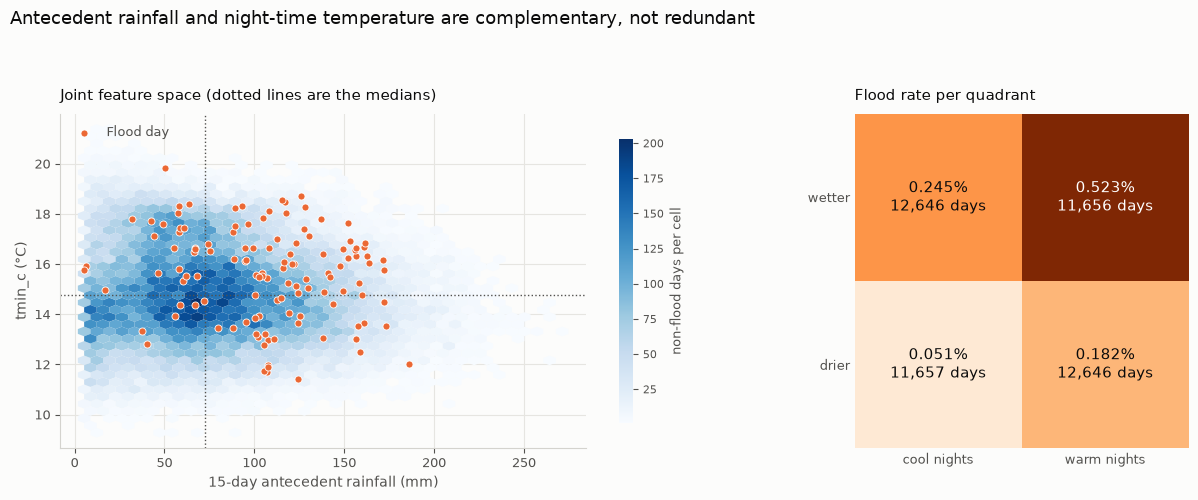

In [10]:
# ante_15d and tmin_c correlate at only 0.04, so the interesting question is
# whether they separate the classes *jointly* better than either does alone
wet = data["ante_15d"] > data["ante_15d"].median()
warm = data["tmin_c"] > data["tmin_c"].median()
quadrant = pd.crosstab(wet, warm, data[LABEL], aggfunc="mean") * 100
counts = pd.crosstab(wet, warm)
print("flood rate (%) by quadrant, rows = wetter than median, cols = warmer nights")
print(quadrant.round(3).to_string())
print()
print(counts.to_string())
lift = quadrant.iloc[1, 1] / quadrant.iloc[0, 0]
print(f"\nwettest-and-warmest quadrant is {lift:.1f}x the driest-and-coolest")

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 5), facecolor=SURFACE,
                                     gridspec_kw={"width_ratios": [1.25, 1]})

# Negatives as density, positives as marks: 121 points would vanish in 48,484
style(left)
mesh = left.hexbin(negatives["ante_15d"], negatives["tmin_c"], gridsize=38,
                   cmap="Blues", mincnt=1, linewidths=0)
left.scatter(positives["ante_15d"], positives["tmin_c"], s=26, color=ORANGE,
             edgecolor="white", linewidth=0.6, zorder=3, label="Flood day")
left.axvline(data["ante_15d"].median(), color=MUTED, linewidth=1, linestyle=":")
left.axhline(data["tmin_c"].median(), color=MUTED, linewidth=1, linestyle=":")
left.set_xlabel("15-day antecedent rainfall (mm)", fontsize=10, color=MUTED)
left.set_ylabel("tmin_c (°C)", fontsize=10, color=MUTED)
left.set_title("Joint feature space (dotted lines are the medians)",
               fontsize=11, color=INK, loc="left", pad=10)
left.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="upper left")
bar = figure.colorbar(mesh, ax=left, shrink=0.85, label="non-flood days per cell")
bar.outline.set_visible(False)
bar.ax.tick_params(colors=MUTED, labelsize=8)
bar.set_label("non-flood days per cell", color=MUTED, fontsize=9)

# The quadrant rates, which is where the complementarity is legible
style(right)
# Reversed so "wetter" sits at the top, matching the scatter beside it where
# the vertical axis also increases upwards
grid_values = quadrant.to_numpy()[::-1]
grid_counts = counts.to_numpy()[::-1]
image = right.imshow(grid_values, cmap="Oranges", vmin=0)
right.set_xticks([0, 1]); right.set_xticklabels(["cool nights", "warm nights"], fontsize=9, color=MUTED)
right.set_yticks([0, 1]); right.set_yticklabels(["wetter", "drier"], fontsize=9, color=MUTED)
right.tick_params(length=0)
right.grid(False)
for spine in right.spines.values():
    spine.set_visible(False)
for i in range(2):
    for j in range(2):
        right.annotate(f"{grid_values[i, j]:.3f}%\n{int(grid_counts[i, j]):,} days",
                       xy=(j, i), ha="center", va="center", fontsize=11,
                       color="#ffffff" if grid_values[i, j] > grid_values.max() * 0.6 else INK)
right.set_title("Flood rate per quadrant", fontsize=11, color=INK, loc="left", pad=10)

figure.suptitle("Antecedent rainfall and night-time temperature are complementary, not redundant",
                fontsize=13, color=INK, x=0.008, ha="left", y=0.99)
figure.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()


### Findings — the two signals combine

The quadrant table is the clearest evidence that `tmin_c` is not repeating the
rainfall signal. Splitting both features at their median gives four groups of
roughly 12,000 district-days each:

| | Cool nights | Warm nights |
| --- | --- | --- |
| **Wetter** | 0.245% | **0.523%** |
| **Drier** | 0.051% | 0.182% |

**The wettest-and-warmest quadrant floods at 10.2x the rate of the
driest-and-coolest.** More importantly, `tmin_c` adds signal *within* each
rainfall level: among wet days, warm nights roughly double the flood rate
(0.245% → 0.523%); among dry days they more than triple it (0.051% → 0.182%).

That is what genuinely complementary features look like, and it is consistent with
their near-zero correlation (r = 0.04). Neither feature is a proxy for the other,
so a model should be able to use both — which is a stronger case for the ERA5 merge
than the univariate AUC of 0.617 makes on its own.

The joint scatter shows why single thresholds will not work: floods appear across
almost the whole feature space, just at higher density towards the upper right.
There is no clean region containing only floods, which is the same conclusion the
threshold analysis reached from one dimension.

## 4. Temporal structure

In [11]:
monthly = data.groupby("month").agg(
    rows=("date", "size"), positives=(LABEL, "sum"),
    rain=("rain_mean", "mean"), antecedent=("ante_15d", "mean"),
)
monthly["floods_per_1000"] = 1000 * monthly["positives"] / monthly["rows"]
monthly["pct_of_positives"] = 100 * monthly["positives"] / monthly["positives"].sum()
print(monthly.round(2).to_string())

# Mount Elgon has two rainy seasons; group to test whether floods follow both
SEASONS = {3: "MAM", 4: "MAM", 5: "MAM", 8: "SON", 9: "SON", 10: "SON", 11: "SON"}
data["season"] = data["month"].map(lambda m: SEASONS.get(m, "dry"))
seasonal = data.groupby("season").agg(rows=("date", "size"), positives=(LABEL, "sum"),
                                      rain=("rain_mean", "mean"))
seasonal["floods_per_1000"] = 1000 * seasonal["positives"] / seasonal["rows"]
print()
print(seasonal.round(2).to_string())

annual = data.groupby("year").agg(rows=("date", "size"), positives=(LABEL, "sum"))
annual["per_1000"] = 1000 * annual["positives"] / annual["rows"]
print()
print(annual.to_string())

       rows  positives  rain  antecedent  floods_per_1000  pct_of_positives
month                                                                      
1      3036          2  1.96       35.13             0.66              1.65
2      3194          1  2.91       37.49             0.31              0.83
3      4189         24  4.45       59.31             5.73             19.83
4      4382         11  7.37       98.87             2.51              9.09
5      4556         25  7.71      120.49             5.49             20.66
6      4339          8  5.23       83.57             1.84              6.61
7      4330          4  5.41       77.65             0.92              3.31
8      4340         19  6.26       94.64             4.38             15.70
9      4199         12  5.50       86.13             2.86              9.92
10     4337         10  5.92       84.27             2.31              8.26
11     4176          4  4.73       80.36             0.96              3.31
12     3527 

In [12]:
train, test = data[data["split"] == "train"], data[data["split"] == "test"]

def ks_statistic(a: np.ndarray, b: np.ndarray) -> float:
    """Two-sample Kolmogorov-Smirnov statistic, computed directly."""
    grid = np.sort(np.concatenate([a, b]))
    ecdf_a = np.searchsorted(np.sort(a), grid, side="right") / len(a)
    ecdf_b = np.searchsorted(np.sort(b), grid, side="right") / len(b)
    return float(np.abs(ecdf_a - ecdf_b).max())


shift = []
for feature in FEATURES:
    a, b = train[feature].to_numpy(), test[feature].to_numpy()
    shift.append({
        "feature": feature,
        "train_mean": a.mean(),
        "test_mean": b.mean(),
        "delta": b.mean() - a.mean(),
        # Expressing the shift in training standard deviations makes it comparable
        "delta_in_sd": (b.mean() - a.mean()) / a.std(),
        "ks": ks_statistic(a, b),
    })
shift = pd.DataFrame(shift)
critical = 1.63 * np.sqrt((len(train) + len(test)) / (len(train) * len(test)))
shift["significant"] = shift["ks"] > critical

print(shift.round(4).to_string(index=False))
print(f"\nKS critical value at p = 0.01 for these sample sizes: {critical:.4f}")

  feature  train_mean  test_mean  delta  delta_in_sd     ks  significant
rain_mean      5.0774     5.6620 0.5846       0.0962 0.0561         True
 rain_max     10.2434    11.5768 1.3334       0.1320 0.0628         True
 rain_min      1.8325     2.0241 0.1916       0.0583 0.0401         True
 ante_15d     76.3272    84.5571 8.2299       0.1864 0.0867         True
   tmax_c     23.4153    23.6916 0.2763       0.1037 0.0458         True
   tmin_c     14.8067    15.2257 0.4190       0.2266 0.0943         True
  tmean_c     19.1391    19.4942 0.3551       0.1825 0.0774         True

KS critical value at p = 0.01 for these sample sizes: 0.0184


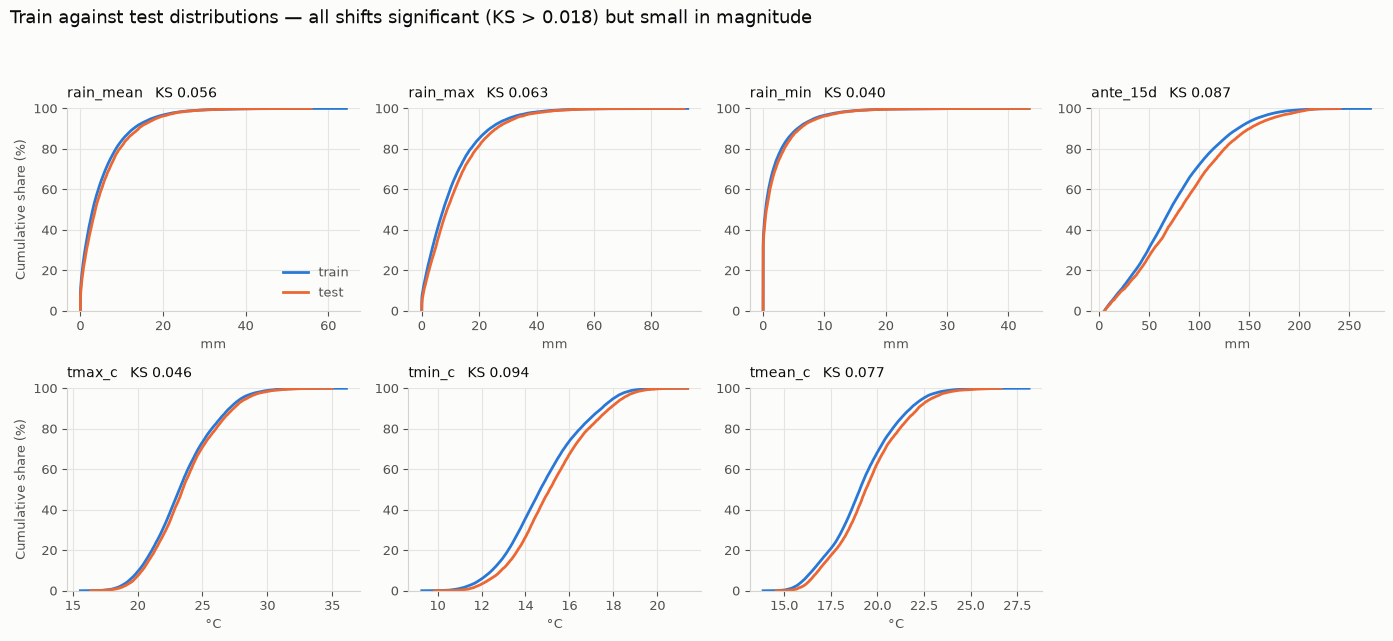

In [13]:
figure, axes = plt.subplots(2, 4, figsize=(14, 6.4), facecolor=SURFACE)
for axis, feature in zip(axes.ravel(), FEATURES):
    style(axis)
    for subset, colour, name in ((train, BLUE, "train"), (test, ORANGE, "test")):
        ordered = np.sort(subset[feature].to_numpy())
        axis.plot(ordered, np.arange(1, len(ordered) + 1) / len(ordered) * 100,
                  color=colour, linewidth=2, label=name)
    row = shift.loc[shift["feature"] == feature].iloc[0]
    axis.set_title(f"{feature}   KS {row['ks']:.3f}", fontsize=10, color=INK, loc="left", pad=8)
    axis.set_xlabel("mm" if feature in RAIN_FEATURES else "°C", fontsize=9, color=MUTED)
    axis.set_ylim(0, 100)
axes.ravel()[0].set_ylabel("Cumulative share (%)", fontsize=9, color=MUTED)
axes.ravel()[4].set_ylabel("Cumulative share (%)", fontsize=9, color=MUTED)
axes.ravel()[0].legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="lower right")
axes.ravel()[-1].axis("off")

figure.suptitle(f"Train against test distributions — all shifts significant "
                f"(KS > {critical:.3f}) but small in magnitude",
                fontsize=13, color=INK, x=0.008, ha="left", y=0.995)
figure.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


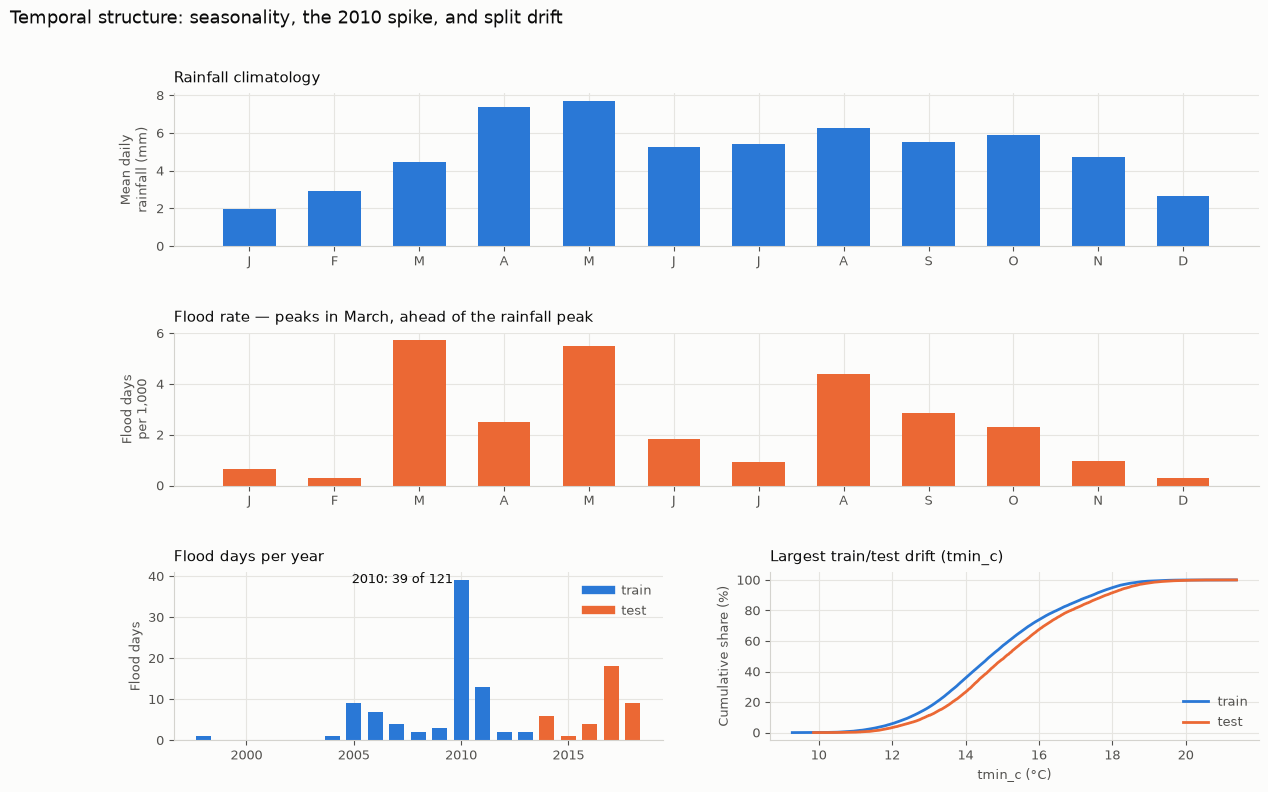

In [14]:
figure = plt.figure(figsize=(14, 8.4), facecolor=SURFACE)
grid = figure.add_gridspec(3, 2, height_ratios=[1, 1, 1.1], hspace=0.55, wspace=0.22)

months = np.arange(1, 13)
labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

# Rainfall and flood rate stacked, never on twin axes - the two measures have
# different units and a shared axis would imply a comparison that does not exist
upper = figure.add_subplot(grid[0, :]); style(upper)
upper.bar(months, monthly["rain"], color=BLUE, width=0.62)
upper.set_xticks(months); upper.set_xticklabels(labels)
upper.set_ylabel("Mean daily\nrainfall (mm)", fontsize=9, color=MUTED)
upper.set_title("Rainfall climatology", fontsize=11, color=INK, loc="left", pad=8)

lower = figure.add_subplot(grid[1, :], sharex=upper); style(lower)
lower.bar(months, monthly["floods_per_1000"], color=ORANGE, width=0.62)
lower.set_xticks(months); lower.set_xticklabels(labels)
lower.set_ylabel("Flood days\nper 1,000", fontsize=9, color=MUTED)
lower.set_title("Flood rate — peaks in March, ahead of the rainfall peak",
                fontsize=11, color=INK, loc="left", pad=8)

# Annual counts, shaded by split
annual_axis = figure.add_subplot(grid[2, 0]); style(annual_axis)
boundary_year = test["year"].min()
colours = [ORANGE if year >= boundary_year else BLUE for year in annual.index]
annual_axis.bar(annual.index, annual["positives"], color=colours, width=0.7)
annual_axis.set_ylabel("Flood days", fontsize=9, color=MUTED)
annual_axis.set_title("Flood days per year", fontsize=11, color=INK, loc="left", pad=8)
annual_axis.annotate("2010: 39 of 121", xy=(2010, 39), xytext=(-6, -2),
                     textcoords="offset points", ha="right", fontsize=9, color=INK)
handles = [plt.Line2D([], [], color=BLUE, linewidth=6, label="train"),
           plt.Line2D([], [], color=ORANGE, linewidth=6, label="test")]
annual_axis.legend(handles=handles, frameon=False, fontsize=9, labelcolor=MUTED)

# Train/test drift on the most-shifted feature
drift_axis = figure.add_subplot(grid[2, 1]); style(drift_axis)
for subset, colour, name in ((train, BLUE, "train"), (test, ORANGE, "test")):
    ordered = np.sort(subset["tmin_c"].to_numpy())
    drift_axis.plot(ordered, np.arange(1, len(ordered) + 1) / len(ordered) * 100,
                    color=colour, linewidth=2, label=name)
drift_axis.set_xlabel("tmin_c (°C)", fontsize=9, color=MUTED)
drift_axis.set_ylabel("Cumulative share (%)", fontsize=9, color=MUTED)
drift_axis.set_title("Largest train/test drift (tmin_c)", fontsize=11, color=INK, loc="left", pad=8)
drift_axis.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="lower right")

figure.suptitle("Temporal structure: seasonality, the 2010 spike, and split drift",
                fontsize=13, color=INK, x=0.008, ha="left", y=0.98)
plt.show()


### Findings — time

**1. Floods are strongly seasonal, and the seasonality is not simply rainfall.**

| Season | Rows | Floods | Rate per 1,000 | Mean rain |
| --- | --- | --- | --- | --- |
| MAM (Mar–May) | 13,127 | 60 | **4.57** | 6.56 mm |
| SON (Aug–Nov) | 17,052 | 45 | 2.64 | 5.61 mm |
| dry | 18,426 | 16 | 0.87 | 3.84 mm |

Both rainy seasons produce floods, at five and three times the dry-season rate.
But the monthly detail contains a genuine anomaly:

| Month | Mean rain | Mean `ante_15d` | Floods per 1,000 |
| --- | --- | --- | --- |
| **March** | 4.45 mm | **59.3 mm** | **5.73** |
| April | 7.37 mm | 98.9 mm | 2.51 |
| May | 7.71 mm | 120.5 mm | 5.49 |

**March has the highest flood rate on the lowest antecedent rainfall of the three.**
It is wetter in April, and far wetter in antecedent terms, yet floods are less than
half as frequent. That ordering cannot be produced by antecedent rainfall alone.

The plausible reading is a wet-season onset effect: March rain falls on soils dried
through January and February, where hard-baked ground and low infiltration produce
rapid runoff. By April the catchment has adjusted. If that holds, **a seasonal term
carries information no rainfall feature can supply**, and month or day-of-year
should be an explicit input — probably cyclically encoded (sin/cos of day-of-year)
rather than as a bare integer.

**2. One year supplies a third of all positives.** 2010 has **39 of 121 flood
days (32%)**, 18 of them in March alone — the Bududa landslide period. 1999–2003
has **zero**. That is 5 consecutive flood-free years in a region averaging six
flood days a year elsewhere in the record: a reporting artefact, not a climate
fact, and a strong argument for the 2005-onward variant flagged in the
class-weighting notebook. It also means cross-validation folds must not be allowed
to treat 2010 as ordinary — any fold containing it is a different problem from one
that does not.

**3. Train/test drift is statistically significant but small.**

| Feature | Train | Test | Δ | Δ in SD | KS |
| --- | --- | --- | --- | --- | --- |
| `tmin_c` | 14.81 | 15.23 | +0.42 | 0.23 | **0.094** |
| `ante_15d` | 76.3 | 84.6 | +8.2 | 0.19 | 0.087 |
| `tmean_c` | 19.14 | 19.49 | +0.36 | 0.18 | 0.077 |
| `rain_mean` | 5.08 | 5.66 | +0.59 | 0.10 | 0.056 |
| `tmax_c` | 23.42 | 23.69 | +0.28 | 0.10 | 0.046 |

Every feature exceeds the KS critical value of 0.0184, so all five shifts are
significant at p < 0.01. **But significance here is a function of sample size, not
of magnitude** — with 38,799 against 9,806 rows, KS detects almost anything. The
effect sizes are 0.10–0.23 standard deviations: the test period is mildly warmer
and wetter, which is what two decades of warming and a later, wetter sample look
like. This is **mild covariate shift, not a regime change**, and does not
invalidate the split. Report it and move on.

`tmin_c` drifting most is worth flagging, since it is also the second-strongest
predictor. A model leaning on it is leaning on the feature that moves most between
periods.

## 5. Anomalies

In [15]:
print("physical plausibility")
checks = {
    "tmin <= tmean <= tmax": ((data["tmin_c"] <= data["tmean_c"])
                              & (data["tmean_c"] <= data["tmax_c"])).all(),
    "rain_min <= rain_mean <= rain_max": ((data["rain_min"] <= data["rain_mean"])
                                          & (data["rain_mean"] <= data["rain_max"])).all(),
    "no negative rainfall": (data[["rain_mean", "rain_max", "rain_min"]] >= 0).all().all(),
    "ante_15d >= same-day rain": (data["ante_15d"] >= data["rain_mean"]).all(),
}
for name, held in checks.items():
    print(f"  {name:<36} {'OK' if held else 'VIOLATED'}")

print(f"\nflood days with implausibly little rain")
print(f"  same-day rain < 1 mm:  {int((positives['rain_mean'] < 1).sum())} of {len(positives)}")
print(f"  ante_15d < 20 mm:      {int((positives['ante_15d'] < 20).sum())}")
print()
print(positives.nsmallest(6, "ante_15d")[
    ["date", "district", "rain_mean", "ante_15d", "tmin_c", "split"]
].to_string(index=False))

print("\nextremes across the frame")
for feature in ["rain_mean", "rain_max", "ante_15d", "tmax_c", "tmin_c"]:
    row = data.loc[data[feature].idxmax()]
    print(f"  max {feature:<10} {row[feature]:>7.2f}  {row['date']:%Y-%m-%d}  {row['district']}")

print("\nhottest days, as a coherence check on the temperature extraction")
print(data.nlargest(4, "tmax_c")[["date", "district", "tmax_c", "tmean_c", "rain_mean"]].to_string(index=False))

physical plausibility
  tmin <= tmean <= tmax                OK
  rain_min <= rain_mean <= rain_max    OK
  no negative rainfall                 OK
  ante_15d >= same-day rain            OK

flood days with implausibly little rain
  same-day rain < 1 mm:  18 of 121
  ante_15d < 20 mm:      3

      date  district  rain_mean  ante_15d    tmin_c split
2014-03-11     MBALE   1.325759  5.295337 15.769151  test
2013-03-05     MBALE   0.128609  6.507299 15.915645 train
2016-01-04   SIRONKO   0.000000 16.868245 14.957877  test
2009-07-21  BUTALEJA   0.061821 31.896626 17.787551 train
2010-01-15 KAPCHORWA   0.286344 37.388903 13.331514 train
2006-07-14 KAPCHORWA   1.739932 40.219008 12.835217 train

extremes across the frame
  max rain_mean    64.42  2011-08-05  KAPCHORWA
  max rain_max     92.64  2006-05-30  BULAMBULI
  max ante_15d    271.28  2007-08-12  KAPCHORWA
  max tmax_c       36.10  2005-02-25  BUTALEJA
  max tmin_c       21.39  2016-02-29  BUTALEJA

hottest days, as a coherence check

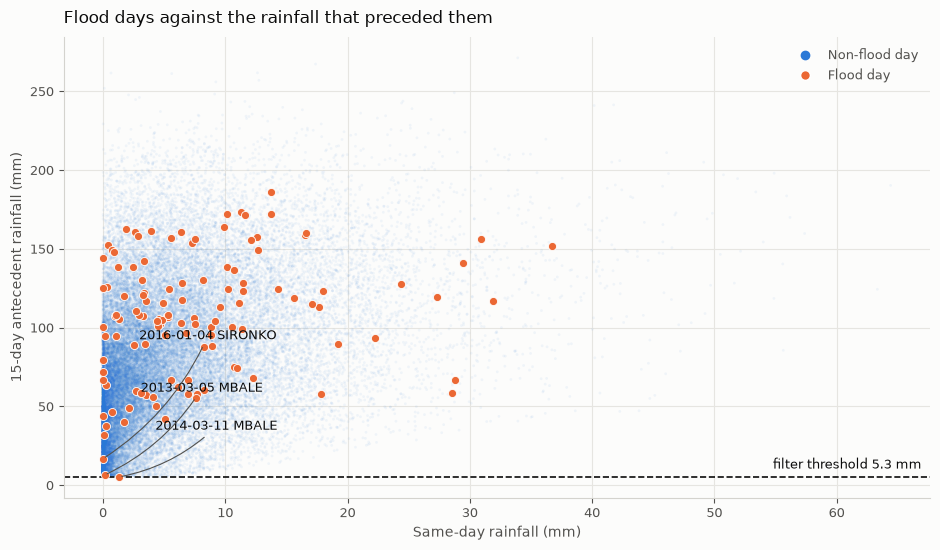

In [16]:
figure, axis = plt.subplots(figsize=(9.5, 5.6), facecolor=SURFACE)
style(axis)

axis.scatter(negatives["rain_mean"], negatives["ante_15d"], s=4, color=BLUE,
             alpha=0.06, edgecolor="none")
axis.scatter(positives["rain_mean"], positives["ante_15d"], s=34, color=ORANGE,
             edgecolor="white", linewidth=0.6, zorder=3, label="Flood day")
axis.axhline(THRESHOLD, color=INK, linewidth=1.2, linestyle="--")
axis.annotate(f"filter threshold {THRESHOLD} mm", xy=(axis.get_xlim()[1], THRESHOLD),
              xytext=(-6, 6), textcoords="offset points", ha="right",
              fontsize=9, color=INK)

# Label the records hardest to explain as rainfall-driven floods, staggering the
# offsets so the three labels do not sit on top of each other
for order, (_, row) in enumerate(positives.nsmallest(3, "ante_15d").iterrows()):
    axis.annotate(f"{row['date']:%Y-%m-%d} {row['district']}",
                  xy=(row["rain_mean"], row["ante_15d"]),
                  xytext=(26, 34 + order * 26), textcoords="offset points",
                  fontsize=9, color=INK,
                  arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8,
                                  connectionstyle="arc3,rad=-0.15"))

axis.set_xlabel("Same-day rainfall (mm)", fontsize=10, color=MUTED)
axis.set_ylabel("15-day antecedent rainfall (mm)", fontsize=10, color=MUTED)
axis.set_title("Flood days against the rainfall that preceded them",
               fontsize=12, color=INK, loc="left", pad=10)
# Proxy handles: the scatter is drawn at alpha 0.06, which is invisible in a legend
handles = [plt.Line2D([], [], marker="o", linestyle="none", markersize=6,
                      color=BLUE, label="Non-flood day"),
           plt.Line2D([], [], marker="o", linestyle="none", markersize=7,
                      color=ORANGE, markeredgecolor="white", label="Flood day")]
axis.legend(handles=handles, frameon=False, fontsize=9, labelcolor=MUTED, loc="upper right")
figure.tight_layout()
plt.show()


### Findings — anomalies

**Every physical invariant holds.** `tmin <= tmean <= tmax` on all 48,605 rows,
`rain_min <= rain_mean <= rain_max` throughout, no negative rainfall, and
`ante_15d` never below the same day's rain. The extraction and merge chain did not
corrupt anything.

**The extremes are physically coherent**, which is a meaningful check on the ERA5
and CHIRPS joins: the four hottest days are all BUTALEJA — the lowland district —
and all four recorded **zero rainfall**. Hot, dry, low-lying. The coldest maximum
belongs to BUDUDA, high on the massif. Temperature tracks elevation and
anti-correlates with rain exactly as it should.

**The label anomalies are the ones needing judgement**, and they are the same
records the threshold analysis surfaced:

| Date | District | Same-day | `ante_15d` | Split |
| --- | --- | --- | --- | --- |
| 2014-03-11 | MBALE | 1.33 mm | **5.30 mm** | test |
| 2013-03-05 | MBALE | 0.13 mm | **6.51 mm** | train |
| 2016-01-04 | SIRONKO | **0.00 mm** | 16.87 mm | test |
| 2009-07-21 | BUTALEJA | 0.06 mm | 31.90 mm | train |

**18 of 121 flood days (15%) record under 1 mm of same-day rain.** That is not
itself suspicious — floods lag their rainfall, which is why `ante_15d` outperforms
same-day rain. But the top two rows are: under 7 mm across a fortnight, in a region
averaging 5.2 mm *per day*, is a drought fortnight ending in a reported flood.

Both are MBALE in March, which is also the anomalous month identified in section 4.
Three readings, in rough order of likelihood: a CHIRPS miss of a localised
convective storm (the district mean smooths a cell-scale downpour), a landslide
logged as a flood — Bududa and Sironko landslides are recorded as `FLOOD` in
DesInventar — or a date error. **None are deleted**; they are flagged here and in
`excluded_positives.csv`. Checking their original DesInventar `Comments` is the
cheapest way to resolve them, and with 121 positives in total, two label errors is
1.7% of the positive class.

## What this means for modelling

Six things follow from the above, roughly in order of how much they matter.

1. **Do not compute temporal features on this file.** It has 3,629 non-random gaps
   and runs of up to 67 missing days. Derive lags and rolling windows from
   `chirps_daily_rainfall.csv`, which is gap-free, then join.

2. **Add a cyclic seasonal feature.** March's flood rate is the highest of any
   month on the *lowest* antecedent rainfall of the three wet-season months —
   structure that no rainfall variable can express. `sin`/`cos` of day-of-year.

3. **Keep `tmin_c`; consider dropping `tmax_c`.** `tmin_c` reaches AUC 0.617 while
   being near-orthogonal to rainfall (r = 0.04), which is the strongest
   justification for the ERA5 merge. `tmax_c` reaches 0.527 and is 0.95 correlated
   with `tmean_c`.

4. **Transform rainfall before scaling.** Skew 1.7–3.4 and 4.8–32% zeros against
   near-Gaussian temperature. `log1p` on the raw rainfall columns.

5. **Benchmark a three-feature model** — `ante_15d`, `rain_mean`, `tmin_c`, plus
   `district` and the seasonal term — against all seven. The seven contain roughly
   three independent signals.

6. **Handle 2010 explicitly in any cross-validation.** It holds 32% of all
   positives; a fold that contains it is a materially different problem from one
   that does not.

And the caveat that outranks all of these: the best single feature reaches AUC
0.694, and the strongest class separation is 0.64 standard deviations. **The
features available separate floods from non-floods weakly.** Class weighting will
make the model attend to the 121 positives; it will not manufacture signal that
is not there. Judge results on precision-recall, and expect modest precision.